# A digital music store, queried in plain SQL

Ten business questions about the **Chinook** sample database (a music store with customers, invoices, tracks, albums and a small sales team), answered with nothing but SQL: joins, CTEs, window functions (`RANK`, `LAG`, `NTILE`, running totals and moving averages), a recursive CTE, a self-join and an anti-join. Python only runs the queries and draws the charts; all the logic lives in the SQL.

> **A note on the data.** Chinook is a teaching database with *generated* sales: revenue is almost flat and customers spend very evenly. So the point of this notebook is the SQL technique, not discovering something about a real business, and the takeaways say so where the data is too regular to conclude anything.

The same queries are in [`chinook_queries.sql`](https://github.com/kagap/python_project/blob/main/mini_projects/09_chinook_sql/chinook_queries.sql).

**Data:** [Chinook database](https://github.com/lerocha/chinook-database) (SQLite edition, 11 tables, 2009-2013). Download `Chinook_Sqlite.sqlite` from the releases page and point `CHINOOK_DB` at it.

In [1]:
import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path(os.environ.get("CHINOOK_DB", "Chinook_Sqlite.sqlite"))
AMBER, BLUE, GREY = "#e8a33d", "#2b6cb0", "#a0aec0"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110})
pd.set_option("display.width", 120)

con = sqlite3.connect(DB_PATH)


def q(sql):
    """Run a query and return the result as a DataFrame."""
    return pd.read_sql_query(sql, con)

## 0. What is in the database?

In [2]:
tables = q("SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name").name
pd.DataFrame({"table": tables,
              "rows": [con.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0] for t in tables]})

,table,rows
0,Album,347
1,Artist,275
2,Customer,59
3,Employee,8
4,Genre,25
5,Invoice,412
6,InvoiceLine,2240
7,MediaType,5
8,Playlist,18
9,PlaylistTrack,8715


## 1. How does revenue develop year by year?

A CTE aggregates invoices per year, and `LAG()` pulls the previous year's revenue onto the same row so growth is a single expression.

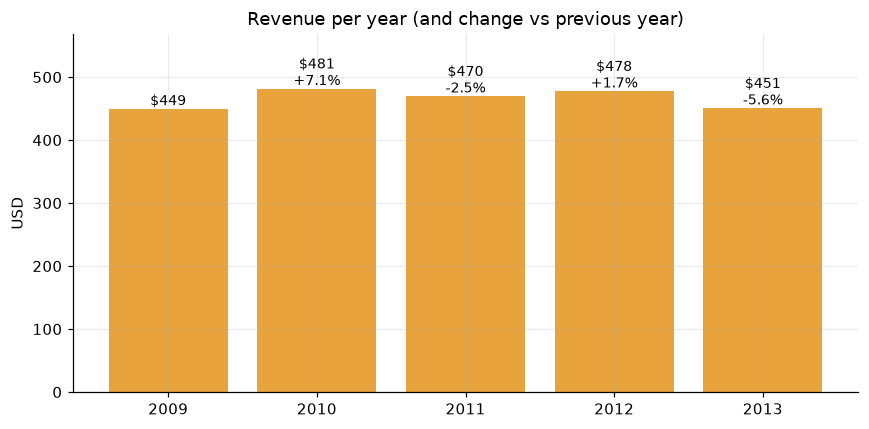

In [3]:
yearly = q("""
WITH yearly AS (
    SELECT CAST(strftime('%Y', InvoiceDate) AS INT) AS year,
           COUNT(*)                                 AS invoices,
           ROUND(SUM(Total), 2)                     AS revenue
    FROM Invoice
    GROUP BY year
)
SELECT year, invoices, revenue,
       ROUND(100.0 * (revenue - LAG(revenue) OVER (ORDER BY year))
                   / LAG(revenue) OVER (ORDER BY year), 1) AS growth_pct
FROM yearly
ORDER BY year
""")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(yearly.year.astype(str), yearly.revenue, color=AMBER)
for x, (rev, g) in enumerate(zip(yearly.revenue, yearly.growth_pct)):
    label = f"${rev:,.0f}" + ("" if pd.isna(g) else f"\n{g:+.1f}%")
    ax.text(x, rev + 6, label, ha="center", fontsize=9)
ax.set_title("Revenue per year (and change vs previous year)")
ax.set_ylabel("USD")
ax.set_ylim(0, yearly.revenue.max() * 1.18)
fig.tight_layout()
plt.show()

## 2. Which artists earn the most?

Sales live on the invoice line, but artists sit three joins away (`InvoiceLine` -> `Track` -> `Album` -> `Artist`).

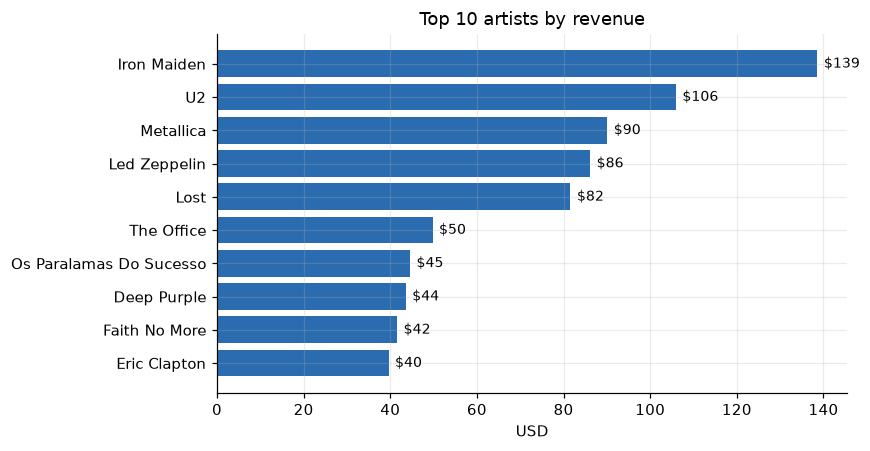

In [4]:
artists = q("""
SELECT ar.Name                                   AS artist,
       ROUND(SUM(il.UnitPrice * il.Quantity), 2) AS revenue,
       COUNT(DISTINCT t.TrackId)                 AS tracks_sold
FROM InvoiceLine il
JOIN Track  t  USING (TrackId)
JOIN Album  al USING (AlbumId)
JOIN Artist ar USING (ArtistId)
GROUP BY ar.ArtistId
ORDER BY revenue DESC
LIMIT 10
""")

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(artists.artist[::-1], artists.revenue[::-1], color=BLUE)
for y, v in enumerate(artists.revenue[::-1]):
    ax.text(v + 1.5, y, f"${v:,.0f}", va="center", fontsize=9)
ax.set_title("Top 10 artists by revenue")
ax.set_xlabel("USD")
fig.tight_layout()
plt.show()

## 3. How concentrated is revenue across genres?

Two window functions over the same grouped result: `SUM(revenue) OVER ()` is the grand total (for the share), and `SUM(revenue) OVER (ORDER BY revenue DESC)` is a running total (for the cumulative, Pareto-style share).

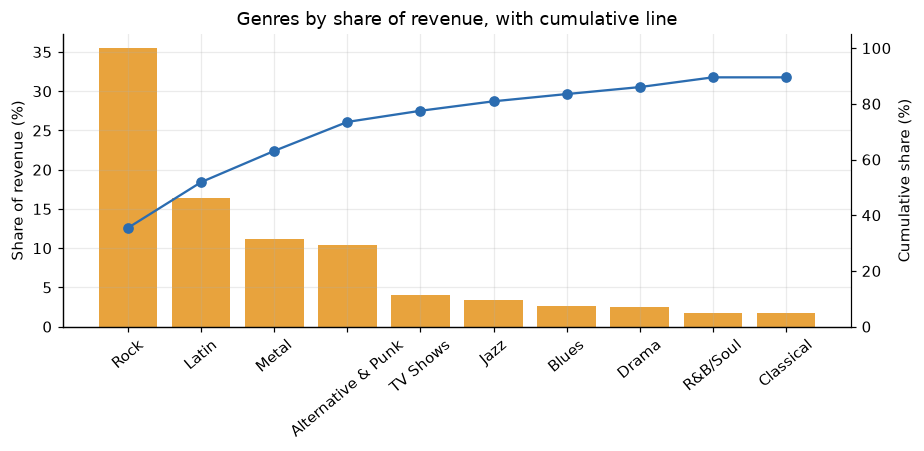

In [5]:
genres = q("""
WITH genre_revenue AS (
    SELECT ge.Name AS genre, SUM(il.UnitPrice * il.Quantity) AS revenue
    FROM InvoiceLine il
    JOIN Track t  USING (TrackId)
    JOIN Genre ge USING (GenreId)
    GROUP BY ge.GenreId
)
SELECT genre,
       ROUND(revenue, 2)                                              AS revenue,
       ROUND(100.0 * revenue / SUM(revenue) OVER (), 1)               AS share_pct,
       ROUND(100.0 * SUM(revenue) OVER (ORDER BY revenue DESC)
                   / SUM(revenue) OVER (), 1)                         AS cumulative_pct
FROM genre_revenue
ORDER BY revenue DESC
LIMIT 10
""")

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.bar(genres.genre, genres.share_pct, color=AMBER)
ax.set_ylabel("Share of revenue (%)")
ax.tick_params(axis="x", rotation=40)
ax2 = ax.twinx()
ax2.plot(genres.genre, genres.cumulative_pct, color=BLUE, marker="o")
ax2.set_ylabel("Cumulative share (%)")
ax2.set_ylim(0, 105)
ax2.grid(False)
ax2.spines["right"].set_visible(True)
ax.set_title("Genres by share of revenue, with cumulative line")
fig.tight_layout()
plt.show()

## 4. Which countries matter most?

`RANK() OVER (ORDER BY revenue DESC)` numbers the countries. Revenue per customer separates a big market from a market that merely has more customers.

In [6]:
countries = q("""
WITH by_country AS (
    SELECT BillingCountry               AS country,
           COUNT(DISTINCT CustomerId)   AS customers,
           SUM(Total)                   AS revenue
    FROM Invoice
    GROUP BY BillingCountry
)
SELECT RANK() OVER (ORDER BY revenue DESC) AS rank,
       country, customers,
       ROUND(revenue, 2)                   AS revenue,
       ROUND(revenue / customers, 2)       AS revenue_per_customer
FROM by_country
ORDER BY rank
LIMIT 10
""")

countries

,rank,country,customers,revenue,revenue_per_customer
0,1,USA,13,523.06,40.24
1,2,Canada,8,303.96,37.99
2,3,France,5,195.10,39.02
3,4,Brazil,5,190.10,38.02
4,5,Germany,4,156.48,39.12
5,6,United Kingdom,3,112.86,37.62
6,7,Czech Republic,2,90.24,45.12
7,8,Portugal,2,77.24,38.62
8,9,India,2,75.26,37.63
9,10,Chile,1,46.62,46.62


## 5. Is there a trend hiding in the monthly numbers?

A window **frame** (`ROWS BETWEEN 2 PRECEDING AND CURRENT ROW`) turns `AVG` into a 3-month moving average, and `PARTITION BY year` makes the running total restart every January.

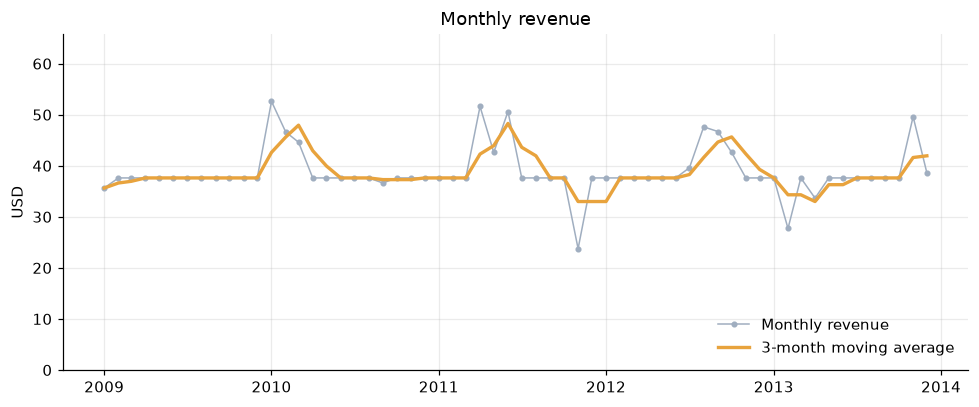

In [7]:
moving_avg = q("""
WITH monthly AS (
    SELECT strftime('%Y-%m', InvoiceDate) AS month, SUM(Total) AS revenue
    FROM Invoice
    GROUP BY month
)
SELECT month,
       ROUND(revenue, 2) AS revenue,
       ROUND(AVG(revenue) OVER (ORDER BY month
                                ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 2) AS moving_avg_3m,
       ROUND(SUM(revenue) OVER (PARTITION BY substr(month, 1, 4)
                                ORDER BY month), 2)                           AS year_to_date
FROM monthly
ORDER BY month
""")

fig, ax = plt.subplots(figsize=(9, 3.8))
x = pd.to_datetime(moving_avg.month)
ax.plot(x, moving_avg.revenue, color=GREY, marker="o", ms=3, lw=1, label="Monthly revenue")
ax.plot(x, moving_avg.moving_avg_3m, color=AMBER, lw=2.2, label="3-month moving average")
ax.set_ylim(0, moving_avg.revenue.max() * 1.25)
ax.set_ylabel("USD")
ax.set_title("Monthly revenue")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

## 6. How does revenue roll up through the sales team?

Employees point at their manager through `ReportsTo`, a tree of unknown depth. A **recursive CTE** starts at the person with no manager and repeatedly joins in their direct reports, building an indented org chart. The `path` column then lets each manager's team revenue be summed over everyone beneath them.

In [8]:
team = q("""
WITH RECURSIVE org AS (                      -- walk the reporting line from the top down
    SELECT EmployeeId, FirstName || ' ' || LastName AS name, Title,
           0 AS depth,
           FirstName || ' ' || LastName            AS path
    FROM Employee
    WHERE ReportsTo IS NULL
    UNION ALL
    SELECT e.EmployeeId, e.FirstName || ' ' || e.LastName, e.Title,
           o.depth + 1,
           o.path || ' > ' || e.FirstName || ' ' || e.LastName
    FROM Employee e
    JOIN org o ON e.ReportsTo = o.EmployeeId
),
rep_revenue AS (
    SELECT c.SupportRepId AS EmployeeId, SUM(i.Total) AS revenue
    FROM Customer c
    JOIN Invoice  i USING (CustomerId)
    GROUP BY c.SupportRepId
)
SELECT substr('— — — ', 1, o.depth * 2) || o.name AS employee,
       o.Title,
       ROUND(COALESCE(rr.revenue, 0), 2)            AS own_revenue,
       ROUND((SELECT SUM(COALESCE(r2.revenue, 0))   -- everyone at or below this person
              FROM org o2
              LEFT JOIN rep_revenue r2 USING (EmployeeId)
              WHERE o2.path LIKE o.path || '%'), 2) AS team_revenue
FROM org o
LEFT JOIN rep_revenue rr USING (EmployeeId)
ORDER BY o.path
""")

team

,employee,Title,own_revenue,team_revenue
0,Andrew Adams,General Manager,0.00,2328.60
1,— Michael Mitchell,IT Manager,0.00,0.00
2,— — Laura Callahan,IT Staff,0.00,0.00
3,— — Robert King,IT Staff,0.00,0.00
4,— Nancy Edwards,Sales Manager,0.00,2328.60
5,— — Jane Peacock,Sales Support Agent,833.04,833.04
6,— — Margaret Park,Sales Support Agent,775.40,775.40
7,— — Steve Johnson,Sales Support Agent,720.16,720.16


## 7. Do customers keep coming back? Cohort retention

Customers are grouped into **cohorts** by the year of their first invoice. For each cohort the query counts how many of its customers bought again 1, 2, 3... years later. Retention is that count divided by the cohort size.

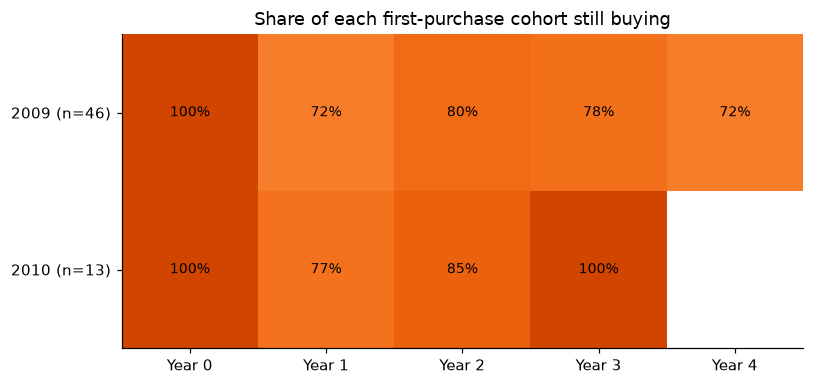

In [9]:
cohorts = q("""
WITH first_year AS (
    SELECT CustomerId, MIN(CAST(strftime('%Y', InvoiceDate) AS INT)) AS cohort
    FROM Invoice
    GROUP BY CustomerId
),
activity AS (
    SELECT DISTINCT CustomerId, CAST(strftime('%Y', InvoiceDate) AS INT) AS year
    FROM Invoice
),
cohort_size AS (
    SELECT cohort, COUNT(*) AS size FROM first_year GROUP BY cohort
)
SELECT f.cohort,
       cs.size                                   AS customers,
       a.year - f.cohort                         AS years_since_first_purchase,
       COUNT(*)                                  AS active_customers,
       ROUND(100.0 * COUNT(*) / cs.size, 0)      AS retention_pct
FROM first_year f
JOIN activity    a  USING (CustomerId)
JOIN cohort_size cs ON cs.cohort = f.cohort
GROUP BY f.cohort, years_since_first_purchase
ORDER BY f.cohort, years_since_first_purchase
""")

matrix = cohorts.pivot(index="cohort", columns="years_since_first_purchase", values="retention_pct")
sizes = cohorts.drop_duplicates("cohort").set_index("cohort").customers
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.imshow(matrix.values, cmap="Oranges", vmin=0, vmax=130, aspect="auto")
ax.set_xticks(range(matrix.shape[1]), [f"Year {c}" for c in matrix.columns])
ax.set_yticks(range(matrix.shape[0]), [f"{c} (n={sizes[c]})" for c in matrix.index])
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        if not np.isnan(matrix.values[i, j]):
            ax.text(j, i, f"{matrix.values[i, j]:.0f}%", ha="center", va="center", fontsize=9)
ax.grid(False)
ax.set_title("Share of each first-purchase cohort still buying")
fig.tight_layout()
plt.show()

## 8. Who are the customers worth a phone call? RFM segmentation

**R**ecency (days since last order), **F**requency (orders) and **M**onetary value (total spent). `NTILE(3)` cuts each into thirds, and a `CASE` expression turns the scores into named segments. "Today" is the date of the last invoice in the data, not the real current date.

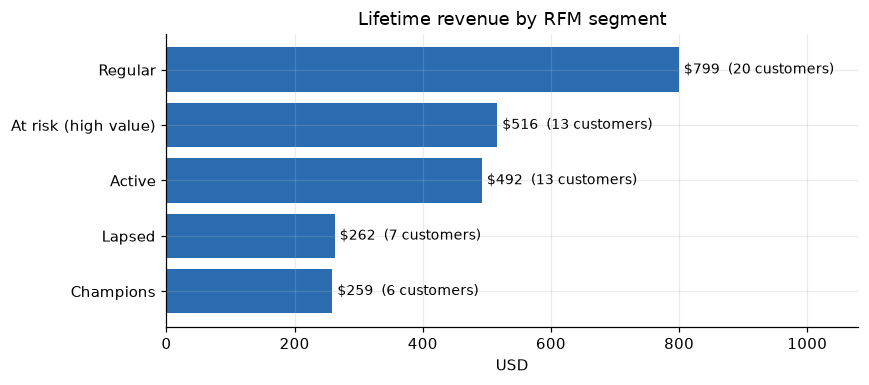

,segment,customers,revenue,avg_days_since_last_order
0,Regular,20,799.40,165.0
1,At risk (high value),13,516.06,417.0
2,Active,13,492.06,46.0
3,Lapsed,7,262.36,397.0
4,Champions,6,258.72,32.0


In [10]:
rfm = q("""
WITH today AS (SELECT MAX(InvoiceDate) AS d FROM Invoice),
base AS (
    SELECT CustomerId,
           CAST(julianday((SELECT d FROM today)) - julianday(MAX(InvoiceDate)) AS INT) AS recency_days,
           COUNT(*)   AS frequency,
           SUM(Total) AS monetary
    FROM Invoice
    GROUP BY CustomerId
),
scored AS (                                  -- 3 = best, 1 = worst on each dimension
    SELECT *,
           NTILE(3) OVER (ORDER BY recency_days DESC) AS r,
           NTILE(3) OVER (ORDER BY frequency)         AS f,
           NTILE(3) OVER (ORDER BY monetary)          AS m
    FROM base
)
SELECT CASE WHEN r = 3 AND m = 3 THEN 'Champions'
            WHEN r = 3             THEN 'Active'
            WHEN r = 1 AND m >= 2  THEN 'At risk (high value)'
            WHEN r = 1             THEN 'Lapsed'
            ELSE                        'Regular' END       AS segment,
       COUNT(*)                          AS customers,
       ROUND(SUM(monetary), 2)           AS revenue,
       ROUND(AVG(recency_days))          AS avg_days_since_last_order
FROM scored
GROUP BY segment
ORDER BY revenue DESC
""")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(rfm.segment[::-1], rfm.revenue[::-1], color=BLUE)
for y, (rev, n) in enumerate(zip(rfm.revenue[::-1], rfm.customers[::-1])):
    ax.text(rev + 8, y, f"${rev:,.0f}  ({n} customers)", va="center", fontsize=9)
ax.set_xlim(0, rfm.revenue.max() * 1.35)
ax.set_title("Lifetime revenue by RFM segment")
ax.set_xlabel("USD")
fig.tight_layout()
plt.show()
rfm

## 9. How much of the catalogue has never sold?

An **anti-join**: `LEFT JOIN` the tracks to the set of tracks that appear on any invoice, and keep the rows where nothing matched (`IS NULL`).

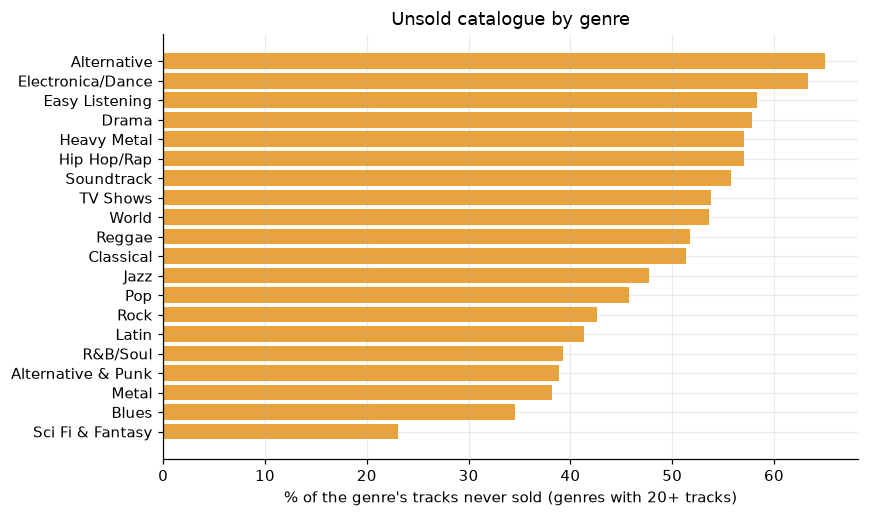

In [11]:
never_sold = q("""
SELECT ge.Name                                              AS genre,
       COUNT(*)                                             AS tracks,
       SUM(sold.TrackId IS NULL)                            AS never_sold,
       ROUND(100.0 * SUM(sold.TrackId IS NULL) / COUNT(*), 1) AS never_sold_pct
FROM Track t
JOIN Genre ge USING (GenreId)
LEFT JOIN (SELECT DISTINCT TrackId FROM InvoiceLine) sold USING (TrackId)   -- anti-join
GROUP BY ge.GenreId
HAVING tracks >= 20
ORDER BY never_sold_pct DESC
""")

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(never_sold.genre[::-1], never_sold.never_sold_pct[::-1], color=AMBER)
ax.set_xlabel("% of the genre's tracks never sold (genres with 20+ tracks)")
ax.set_title("Unsold catalogue by genre")
fig.tight_layout()
plt.show()

## 10. Which genres are bought together?

A **self-join** of the invoice/genre table pairs up genres that appear on the same invoice. *Lift* compares how often a pair occurs with how often it would occur if the two genres were bought independently: above 1 means they go together, below 1 means they avoid each other.

In [12]:
basket = q("""
WITH invoice_genres AS (
    SELECT DISTINCT il.InvoiceId, t.GenreId
    FROM InvoiceLine il
    JOIN Track t USING (TrackId)
),
total AS (SELECT COUNT(DISTINCT InvoiceId) AS n FROM invoice_genres),
single AS (SELECT GenreId, COUNT(*) AS invoices FROM invoice_genres GROUP BY GenreId),
pairs AS (                                   -- self-join: two genres on the same invoice
    SELECT a.GenreId AS g1, b.GenreId AS g2, COUNT(*) AS together
    FROM invoice_genres a
    JOIN invoice_genres b ON a.InvoiceId = b.InvoiceId AND a.GenreId < b.GenreId
    GROUP BY a.GenreId, b.GenreId
)
SELECT ga.Name AS genre_a, gb.Name AS genre_b, p.together,
       ROUND(1.0 * p.together * t.n / (sa.invoices * sb.invoices), 2) AS lift
FROM pairs p
CROSS JOIN total t
JOIN single sa ON sa.GenreId = p.g1
JOIN single sb ON sb.GenreId = p.g2
JOIN Genre  ga ON ga.GenreId = p.g1
JOIN Genre  gb ON gb.GenreId = p.g2
WHERE p.together >= 20
ORDER BY p.together DESC
LIMIT 10
""")

basket

,genre_a,genre_b,together,lift
0,Rock,Alternative & Punk,54,1.11
1,Rock,Latin,51,0.83
2,Rock,Metal,46,0.91
3,Metal,Latin,25,0.92
4,Rock,Jazz,24,1.12
5,Alternative & Punk,Latin,20,0.76


## What the queries say

Remember the caveat: this is a generated sample database, so read these as demonstrations of what each query can surface, not as facts about a real store.

- **Revenue is flat.** Between $449 and $481 a year, never moving more than about 7% from one year to the next. The monthly line is steady at roughly $37.62 with occasional spikes and dips, so the moving average mostly shows how a window frame smooths a handful of outliers.
- **Genre concentration is the one strong pattern.** Rock alone is 35.5% of revenue and the top four genres (Rock, Latin, Metal, Alternative & Punk) are 73.5%. Iron Maiden is the top artist at $138.60.
- **Countries differ in size, not in value.** The USA brings in $523 (about 22% of revenue) simply because it has the most customers (13). Revenue per customer is $38-$40 in most markets (the highest are Chile at $47 and the Czech Republic at $45, each with only one or two customers).
- **Retention is high but there are only two cohorts.** 46 customers joined in 2009 and 13 in 2010, nobody after that. In each later year 72-100% of a cohort is still buying, which is far steadier than a real shop would be.
- **RFM finds a group worth calling.** 13 customers with mid-to-high spend have not ordered for about 417 days on average (revenue $516), the "at risk (high value)" segment a real team would contact first.
- **43% of the catalogue never sold.** 1,519 of 3,503 tracks, rising to 65% in Alternative. In a real business that is a question about stock, licensing or discoverability.
- **No genre affinity.** Lift for every common genre pair is between 0.76 and 1.12, close to 1, meaning invoices look like random baskets. A real store would show stronger pairs, and that is a nice reminder that a query can only report what the data contains.
- **The team tree rolls up cleanly.** Nancy Edwards manages all three sales agents and so owns 100% of the $2,329 in revenue, with Jane Peacock the biggest single contributor at $833.

**Techniques covered:** inner, left, self- and anti-joins, CTEs, a recursive CTE, `RANK`, `LAG`, `NTILE`, `SUM() OVER` with and without a frame, conditional aggregation and `CASE`.
